# Tarea: Simulación de cadenas de Markov

**Integrantes**
* Centeno López Shani Samantha
* Miguel Zepeda Alejandra
* Rodríguez Loyola Danna Carolina
* Sánchez Escobar Yuliana
* Velázquez Castillo Alma Ali

**Equipo 4**


**Ejercicio 1**

Para la cadena de Markov con espacio de estados {0, 1, 2, 3, 4, 5} vista en los ejemplos de la clase, cuya matriz de transición es

\begin{pmatrix}
1 & 0 & 0 & 0 & 0 & 0\\
\frac{1}{4} & \frac{1}{2} & \frac{1}{4} & 0 & 0 & 0\\
0 & 0 & 0 & \frac{1}{6} & \frac{1}{3} & \frac{1}{2}\\
0 & 0 & 0 & \frac{1}{2} & 0 & \frac{1}{2}\\
0 & 0 & 0 & \frac{1}{4} & 0 & \frac{3}{4}
\end{pmatrix}

Para cada estado de la cadena i simula 1000 realizaciones de 10000 pasos iniciando en i

* ¿Qué porcentaje de veces la cadena que inicia en i se absorbe en 0?

* ¿Qué porcentaje de veces se absorbe en {3,4,5}?

* En cada una de las trayectorias, observa cuántas veces se visita el estado 5 (sin contar el tiempo 0). Discute tus resultados. Pista: no existe una única distribución estacionaria para esta cadena; aun así responde qué puedes observar y discute.

* Compara estos resultados con lo que calculamos en clase para esta cadena.


Resultados de Absorción (en porcentaje de realizaciones)
                    Absorción en {0}  Absorción en {3,4,5}
Estado Inicial (i)                                        
0                              100.0                   0.0
1                               61.2                  38.8
2                               18.4                  81.6
3                                0.0                 100.0
4                                0.0                 100.0
5                                0.0                 100.0

Estadísticas del Número de Visitas al Estado 5 (N=10000 pasos)
 Estado Inicial (i)  Media Visitas 5  Desv. Est. Visitas 5
                  0             0.00                  0.00
                  1          2079.27               4057.34
                  2          4129.48               4923.10
                  3          4880.00               4998.56
                  4          5150.00               4997.75
                  5          7440.00               4

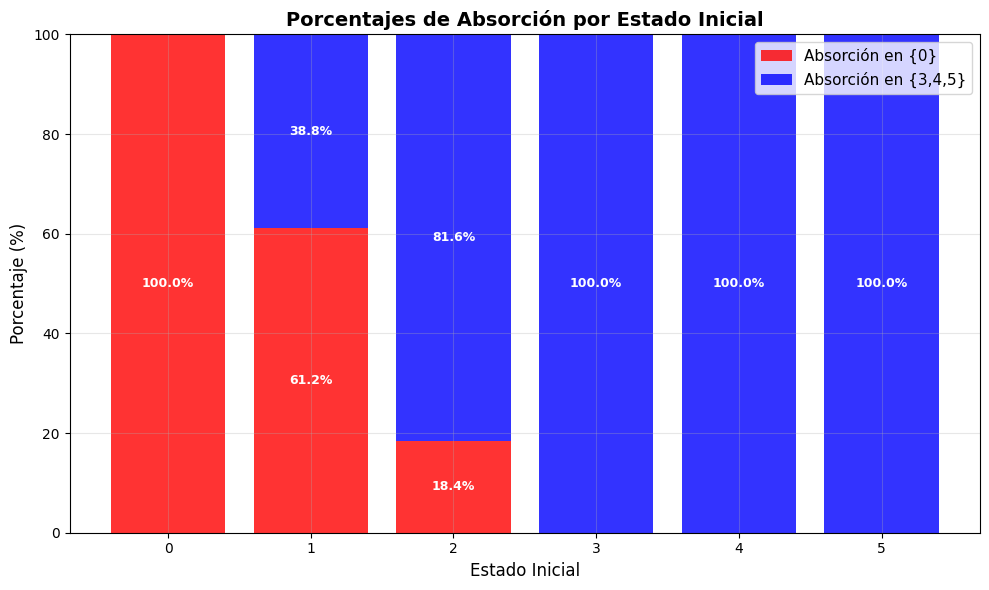

<Figure size 640x480 with 0 Axes>

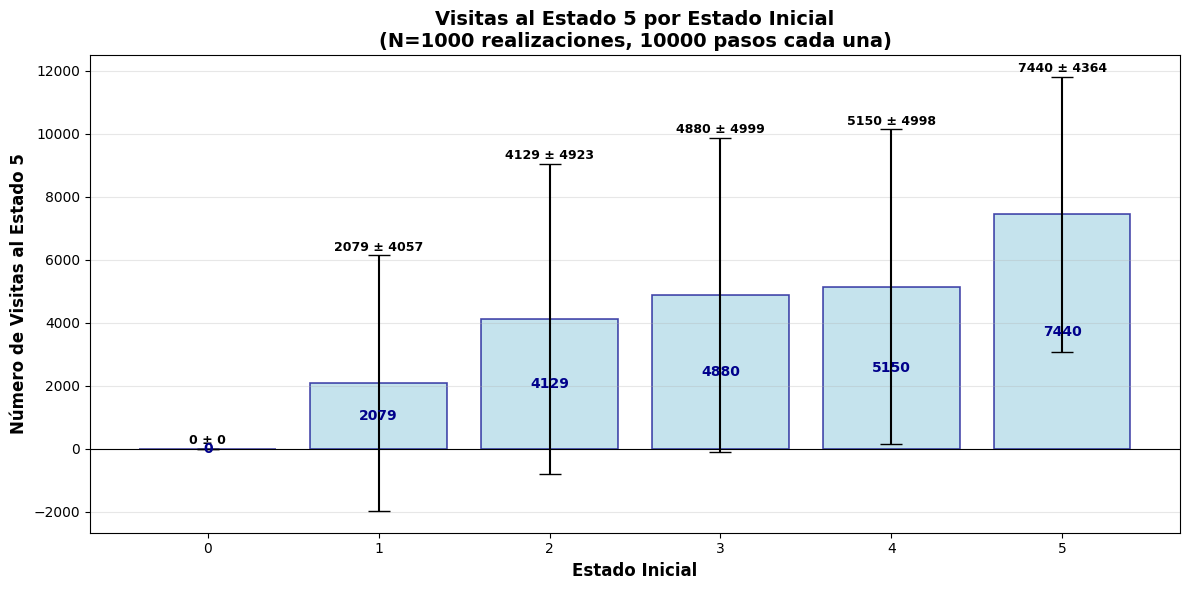

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Definición de la matriz de transición P
P = np.array([
    [1, 0, 0, 0, 0, 0],
    [1/4, 1/2, 1/4, 0, 0, 0],
    [0, 1/5, 2/5, 1/5, 0, 1/5],
    [0, 0, 0, 1/6, 1/3, 1/2],
    [0, 0, 0, 1/2, 0, 1/2],
    [0, 0, 0, 1/4, 0, 3/4]
])

# Parámetros de la simulación
N_pasos = 10000
N_realizaciones = 1000
estados = list(range(P.shape[0]))  # {0, 1, 2, 3, 4, 5}
estados_absorbentes_1 = {0}
estados_absorbentes_2 = {3, 4, 5}
estados_absorbentes_union = estados_absorbentes_1.union(estados_absorbentes_2)
estado_a_contar = 5

# Estructura para almacenar los resultados
resultados_absorcion = {i: {'absorcion_0': 0, 'absorcion_345': 0} for i in estados}
visitas_estado_5 = {i: [] for i in estados}

# 2. Función de simulación de una trayectoria
def simular_cadena(P, estado_inicial, pasos_max):
    """Simula una trayectoria de la CM y devuelve la secuencia de estados."""
    estado_actual = estado_inicial
    trayectoria = [estado_actual]

    # Simulación de la trayectoria
    for _ in range(pasos_max):
        # La probabilidad de pasar de 'estado_actual' al siguiente es la fila P[estado_actual, :]
        proximos_estados = np.arange(P.shape[1])
        proximos_probs = P[estado_actual, :]

        # Selección aleatoria del siguiente estado
        estado_siguiente = np.random.choice(proximos_estados, p=proximos_probs)
        trayectoria.append(estado_siguiente)
        estado_actual = estado_siguiente

        # Criterio de parada por absorción (si ya fue absorbida, no tiene sentido continuar)
        if estado_actual in estados_absorbentes_union:
             # Si se absorbe, llenamos el resto de la trayectoria con el estado absorbente
             trayectoria.extend([estado_actual] * (pasos_max - len(trayectoria) + 1))
             break

    return np.array(trayectoria)

# 3. Ejecución de las simulaciones

for i in estados: # Para cada estado inicial
    for _ in range(N_realizaciones):
        trayectoria = simular_cadena(P, i, N_pasos)

        # El último estado alcanzado es el de absorción
        estado_final = trayectoria[-1]

        # a) Absorción en {0}
        if estado_final in estados_absorbentes_1:
            resultados_absorcion[i]['absorcion_0'] += 1

        # b) Absorción en {3, 4, 5}
        elif estado_final in estados_absorbentes_2:
            resultados_absorcion[i]['absorcion_345'] += 1

        # c) Conteo de visitas al estado 5 (sin contar el tiempo 0)
        # Contamos desde el tiempo 1 hasta el final
        conteo_visitas_5 = np.sum(trayectoria[1:] == estado_a_contar)
        visitas_estado_5[i].append(conteo_visitas_5)

# 4. Cálculo de porcentajes de absorción
porcentajes = {}
for i in estados:
    total = N_realizaciones
    porcentaje_0 = (resultados_absorcion[i]['absorcion_0'] / total) * 100
    porcentaje_345 = (resultados_absorcion[i]['absorcion_345'] / total) * 100

    porcentajes[i] = {
        'Absorción en {0}': porcentaje_0,
        'Absorción en {3,4,5}': porcentaje_345
    }

# Convertir a DataFrame para mejor visualización
df_porcentajes = pd.DataFrame.from_dict(porcentajes, orient='index')
df_porcentajes.index.name = 'Estado Inicial (i)'

print("\n" + "="*50)
print("Resultados de Absorción (en porcentaje de realizaciones)")
print("="*50)
print(df_porcentajes.round(2))
print("="*50)

# 5. Cálculo y visualización de estadísticas de visitas
df_visitas = pd.DataFrame({
    'Estado Inicial (i)': estados,
    'Media Visitas 5': [np.mean(visitas_estado_5[i]) for i in estados],
    'Desv. Est. Visitas 5': [np.std(visitas_estado_5[i]) for i in estados]
})

print("\n" + "="*70)
print(f"Estadísticas del Número de Visitas al Estado 5 (N={N_pasos} pasos)")
print("="*70)
print(df_visitas.to_string(index=False, float_format="%.2f"))
print("="*70)

# =============================================================================
# GRÁFICO DE PORCENTAJES DE ABSORCIÓN
# =============================================================================

plt.figure(figsize=(10, 6))

# Datos para el gráfico
x = estados
y1 = [porcentajes[i]['Absorción en {0}'] for i in estados]
y2 = [porcentajes[i]['Absorción en {3,4,5}'] for i in estados]

# Crear gráfico de barras apiladas
plt.bar(x, y1, label='Absorción en {0}', alpha=0.8, color='red')
plt.bar(x, y2, bottom=y1, label='Absorción en {3,4,5}', alpha=0.8, color='blue')

# Configurar el gráfico
plt.xlabel('Estado Inicial', fontsize=12)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.title('Porcentajes de Absorción por Estado Inicial', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(estados)

# Añadir valores en las barras
for i, (v1, v2) in enumerate(zip(y1, y2)):
    if v1 > 5:  # Solo mostrar texto si el valor es suficientemente grande
        plt.text(i, v1/2, f'{v1:.1f}%', ha='center', va='center',
                fontweight='bold', color='white', fontsize=9)
    if v2 > 5:
        plt.text(i, v1 + v2/2, f'{v2:.1f}%', ha='center', va='center',
                fontweight='bold', color='white', fontsize=9)

plt.tight_layout()
plt.show()


plt.tight_layout(pad=3.0)  # Más espacio alrededor de todo el gráfico
plt.show()

# =============================================================================
# GRÁFICO DE VISITAS AL ESTADO 5
# =============================================================================

plt.figure(figsize=(12, 6))

# Datos para el gráfico
medias = [np.mean(visitas_estado_5[i]) for i in estados]
desviaciones = [np.std(visitas_estado_5[i]) for i in estados]

# Crear gráfico de barras con barras de error
barras = plt.bar(estados, medias, yerr=desviaciones, capsize=8,
                 alpha=0.7, color='lightblue', edgecolor='darkblue', linewidth=1.2)

# Configurar el gráfico
plt.xlabel('Estado Inicial', fontsize=12, fontweight='bold')
plt.ylabel('Número de Visitas al Estado 5', fontsize=12, fontweight='bold')
plt.title(f'Visitas al Estado 5 por Estado Inicial\n(N={N_realizaciones} realizaciones, {N_pasos} pasos cada una)',
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.xticks(estados)

# Añadir valores en las barras
for i, (media, desv) in enumerate(zip(medias, desviaciones)):
    plt.text(i, media + desv + 50, f'{media:.0f} ± {desv:.0f}',
             ha='center', va='bottom', fontweight='bold', fontsize=9)
    plt.text(i, media/2, f'{media:.0f}', ha='center', va='center',
             fontweight='bold', color='darkblue', fontsize=10)

# Añadir línea horizontal para referencia
plt.axhline(y=0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()




*   ¿Que porcentaje de veces la cadena que inicia en i se absorbe en 0?

    Si el estado incial es i = 0 entonces la cadena se absorbe el 100% de las veces en cero.

    Si el estado incial es i = 1 entonces la cadena se absorbe el 59.3% de las veces en cero.

    Si el estado incial es i = 2 entonces la cadena se absorbe el 18.6% de las veces en cero.

    Si el estado incial es i = 3,4,5 entonces la cadena nunca se absorbe en cero.



*   ¿Qué porcentaje de veces la cadena que inicia en i se absorbe en {3,4,5}?

    Si el estado incial es i = 0 entonces la cadena nunca se absorbe en {3,4,5}

    Si el estado incial es i = 2 entonces la cadena se absorbe el 40.7% de las veces en {3,4,5}

    Si el estado incial es i = 3,4,5 entonces la cadena se absorbe el 100% de las veces en {3,4,5}



*   En cada una de las trayectorias, observa cuántas veces se visita el estado 5 (sin contar el
tiempo 0).

    Aproximadamente el estado 1 visita 2079 veces el estado 5

    Aproximadamente el estado 2 viista 4129 veces el estado 5

    Aproximadamente el estado 3 visita 4880 veces el estado 5

    Aproximadamente el estado 4 visita 5150 veces el estado 5

    Aproximadamente el estado 5 visita 7440 veces el estado 5



*   Observaciones

    Al igual que en clase, se tiene que tenemos dos clases cerradas {0} y {3,4,5}.Al tener más de una clase cerrada sabemos que no va a existir una única distribución. Concluimos también que la probabilidad de absorbernos en la clase {3,4,5} empezando en cero es igual a cero, y por ser clase cerrada, con probabilidad 1 podemos caer en la clase {3,4,5} iniciando en cualquiera de los 3 estados que conforman la clase.

    Como se obtuvo en clase con probabilidad 2/5 nos absorbiamos en la clase {3,4,5} empezando en el estado 1.

    Y con probabilidad 4/5 nos absorbiamos en la clase {3,4,5} empezando en el estado 2.
















**Ejercicio 2**

Para la cadena de Markov con espacio de estados {0, 1, 2, 3} y con matriz de transición

\begin{pmatrix}
\frac{1}{2} & \frac{1}{2} & 0 & 0 \\
\frac{1}{6} & \frac{1}{2} & \frac{1}{3} & 0 \\
0 & \frac{1}{3} & \frac{1}{2} & \frac{1}{6} \\
0 & 0 & \frac{1}{2} & \frac{1}{2}
\end{pmatrix}

Simula una realización de 1000 pasos de la cadena.

In [ ]:
import numpy as np

np.random.seed(42)

# Espacio de estados
states = np.array([0, 1, 2, 3])

# Matriz de transición P
P = np.array([
    [1/2, 1/2, 0,   0  ],
    [1/6, 1/2, 1/3, 0  ],
    [0,   1/3, 1/2, 1/6],
    [0,   0,   1/2, 1/2]
], dtype=float)

# Simular 1000 pasos
n_steps = 1000

# Usando una distribución uniforme
pi0 = np.array([0.25, 0.25, 0.25, 0.25], dtype=float)

# Elegir estado inicial de acuerdo a pi0
current_state = np.random.choice(states, p=pi0)

# Guardar trayectoria
trajectory = np.empty(n_steps + 1, dtype=int)
trajectory[0] = current_state

# Distribuciones acumuladas por fila
cdf = np.cumsum(P, axis=1)

# Dada la fila 's', muestrea próximo estado según P[s, :]
def next_state_from(s):
    r = np.random.random()
    return np.searchsorted(cdf[s], r)

# Simular
for t in range(1, n_steps + 1):
    current_state = next_state_from(current_state)
    trajectory[t] = current_state

# Frecuencias de visita
unique, counts = np.unique(trajectory, return_counts=True)
freq = counts / trajectory.size

print("Estados de la trayectoria:")
print(trajectory[:1000])

print("\nFrecuencias de visita:")
for s, f, c in zip(unique, freq, counts):
    print(f"Estado {s}: {f:.4f} (visitas = {c})")

Estados de la trayectoria:
[1 2 2 2 1 0 0 1 1 2 1 2 2 1 1 1 1 1 1 1 1 0 0 0 0 1 1 1 1 0 1 1 0 1 2 2 1
 0 1 1 0 0 0 1 1 1 1 1 1 1 2 2 3 3 3 3 2 1 0 0 0 0 1 1 1 1 0 1 0 1 2 1 0 1
 2 2 2 1 1 0 1 1 1 0 0 0 1 1 2 2 1 2 2 2 2 2 2 2 1 0 0 1 1 1 2 1 1 2 1 0 0
 0 1 2 2 3 3 2 3 3 3 3 2 1 1 1 2 3 2 2 2 1 0 0 1 1 1 2 2 3 3 2 2 1 1 0 1 1
 0 0 1 1 0 0 1 1 2 2 1 2 2 2 2 2 1 2 1 1 0 1 2 1 1 1 1 1 2 2 3 2 2 1 2 3 2
 2 2 2 2 1 0 1 2 2 2 2 2 3 3 3 3 2 1 2 2 1 0 1 0 0 1 2 2 1 2 1 1 2 2 3 3 3
 2 2 1 1 2 2 3 3 3 3 3 2 1 2 1 0 1 1 2 3 3 2 1 2 2 3 3 3 2 2 3 2 1 1 2 2 2
 1 1 2 1 1 2 2 2 2 2 1 2 2 3 3 3 3 3 3 3 3 3 2 2 1 1 0 0 1 1 1 0 0 1 1 0 1
 2 1 1 0 0 1 1 1 2 3 3 2 2 1 1 0 0 1 2 2 2 1 0 0 1 2 2 1 2 2 2 2 2 1 1 2 1
 0 0 0 1 2 2 1 1 1 1 1 1 1 1 0 0 1 1 2 2 1 0 1 0 1 2 2 2 2 2 2 3 2 3 3 2 1
 0 0 0 1 0 0 1 0 1 1 0 1 1 2 2 2 1 1 2 2 3 2 2 2 2 3 3 2 2 2 1 2 2 2 1 2 2
 1 2 1 1 2 3 3 3 2 1 1 2 2 2 2 1 1 0 1 1 2 2 1 0 1 1 0 0 1 0 1 2 1 0 1 1 1
 2 3 3 3 2 1 2 2 2 3 2 2 1 1 0 0 0 1 2 2 3 2 1 2 1 2 1 2 1 2 2 3 2 2 3 3 

* ¿Cuántas veces la cadena visita el estado 0?
156 veces

* ¿Cuántas veces la cadena visita el estado 1?
378 veces

* ¿Cuántas veces la cadena visita el estado 2?
344 veces

* ¿Cuántas veces la cadena visita el estado 3?
123 veces

Discute tus resultados obtenidos vía simulación al compararlos con la distribución estacionaria de esta cadena (ver ejemplos de la clase 02-10 en las notas del Classroom).


Sabemos que la distribución estacionaria es: π = (1/8, 3/8, 1/8, 3/8​)=(0.125,0.375,0.375,0.125)

Entonces para una simulación de 1000 pasos tenemos que los valores esperados son:

𝔼[número de visitas] = 1000 * π = (125,375,375,125)


Es decir:

Para el estado 0 tenemos 125

Para el estado 1 tenemos 375

Para el estado 2 tenemos 375

Para el estado 3 tenemos 125


Dado que la cadena es irreducible y aperiódica, como vimos en el ejemplo de la clase, entonces por la ley de los grandes números para cadenas de Markov debería converger a π, esto cuando el número de visitas tiende a ∞, sin embargo, como vemos en la simulación se aproxima a π pero no es exactamente π, por lo que podemos decir que es necesario un número más grande pues 1000 visitas no fueron suficientes por ser un número finito pequeño.

Diferencias:

Para el estado 0: 156 - 125 = 31  ⇒ la diferencia es de 0.031 proporcionalmente

Para el estado 1: 378 - 375 = 3  ⇒ la diferencia es de 0.031 proporcionalmente

Para el estado 2: 344 - 375 = -31  ⇒

Para el estado 3: 123- 125 = -2  ⇒

Para los tiempos 100, 200, 300, . . . , 1000, grafica el acumulado de visitas a cada estado.

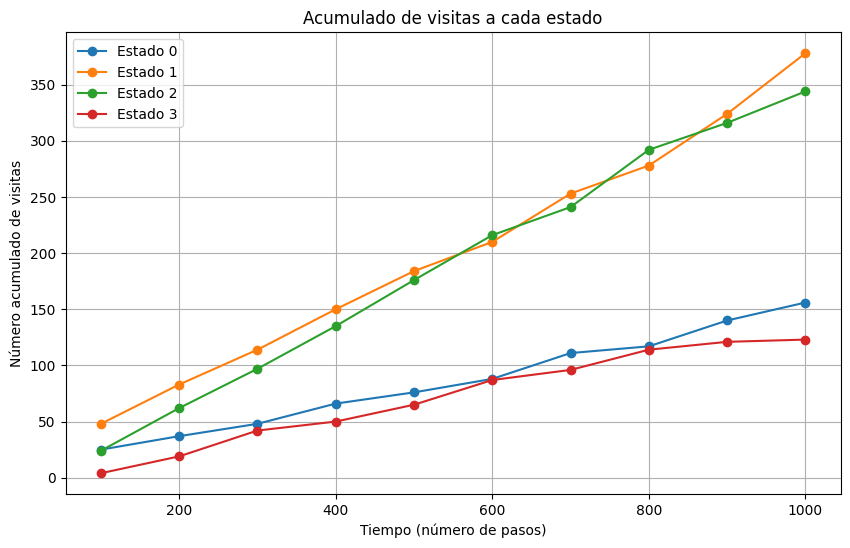

In [ ]:
# Gráfica de visitas acumuladas en cada estado

import matplotlib.pyplot as plt

# Tiempos
times = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]

# Número de estados
n_states = len(states)

# Matriz para el conteo
visit_counts = np.zeros((len(times), n_states), dtype=int)

# Acumulados hasta EL tiempo t
for i, t in enumerate(times):
    for s in range(n_states):
        visit_counts[i, s] = np.sum(trajectory[:t+1] == s)

# Grafica
plt.figure(figsize=(10, 6))
for s in range(n_states):
    plt.plot(times, visit_counts[:, s], marker='o', label=f"Estado {s}")

plt.title("Acumulado de visitas a cada estado")
plt.xlabel("Tiempo (número de pasos)")
plt.ylabel("Número acumulado de visitas")
plt.legend()
plt.grid(True)
plt.show()

**Ejercicio 3**

Para la cadena de Markov con espacio de estados {0, 1, 2, 3} y con matriz de transición

\begin{pmatrix}
0 & 1 & 0 & 0 \\
\frac{1}{3} & 0 & \frac{2}{3} & 0 \\
0 & \frac{2}{3} & 0 & \frac{1}{3} \\
0 & 0 & 1 & 0
\end{pmatrix}

Simula 1000 realizaciones de 10000 pasos de la cadena iniciando en 0 y responde:

* ¿Cuántas veces la cadena termina en el estado 0? 248 veces
* ¿En el estado 1? 0
* ¿En el estado 2? 752
* ¿En el estado 3? 0

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

In [ ]:
# Definimos la matriz de transición
P = np.array([
    [0, 1, 0, 0],
    [1/3, 0, 2/3, 0],
    [0, 2/3, 0, 1/3],
    [0, 0, 1, 0]
])

estados = [0, 1, 2, 3]

# Estado inicial para todas las simulaciones
estado_inicial = 0

# Número de simulaciones
num_simulaciones = 1000

# Creamos una función para simular una cadena de Markov
def simulacion_cadena(estado_inicial, pasos, P, num_simulaciones):
    resultados = []  # Lista para guardar todos los estados

    for i in range(num_simulaciones):   #hacer 1000 simulaciones
      estado_actual = estado_inicial

      for _ in range(pasos):
        # Dependiendo del lugar en el que se encuentre, se elige aleatoriamente
        # entre los estados para moverse dependiendo su probabilidad
        estado_actual = np.random.choice(estados, p=P[estado_actual])

      resultados.append(estado_actual)

    # Contamos la frecuencia de cada estado final
    conteo_final = Counter(resultados)

    # Aseguramos que todos los estados (0, 1, 2, 3) estén en el diccionario
    frecuencias = {i: conteo_final.get(i, 0) for i in estados}

    return frecuencias

In [ ]:
# Simulación 1: 10000 pasos
np.random.seed(319032680)
pasos_1 = 10000
frecuencias_10000 = simulacion_cadena(estado_inicial, pasos_1, P, num_simulaciones)
proporciones_10000 = {k: v / num_simulaciones for k, v in frecuencias_10000.items()}

print(f"Resultados para {num_simulaciones} realizaciones de {pasos_1} pasos iniciando en {estado_inicial}")
for estado in estados:
    frecuencia = frecuencias_10000[estado]
    proporcion = proporciones_10000[estado] * 100
    print(f"Estado {estado}: Termina {frecuencia} veces ({proporcion:.2f}%)")

Resultados para 1000 realizaciones de 10000 pasos iniciando en 0
Estado 0: Termina 248 veces (24.80%)
Estado 1: Termina 0 veces (0.00%)
Estado 2: Termina 752 veces (75.20%)
Estado 3: Termina 0 veces (0.00%)


Ahora simula 1000 realizaciones de 10001 pasos de la cadena iniciando en 0 y responde:

* ¿Cuántas veces la cadena termina en el estado 0? 0
* ¿En el estado 1? 741
* ¿En el estado 2? 0
* ¿En el estado 3? 259

In [ ]:
# Simulación 2: 10001 pasos
np.random.seed(319032680)
pasos_2 = 10001
frecuencias_10001 = simulacion_cadena(estado_inicial, pasos_2, P, num_simulaciones)
proporciones_10001 = {k: v / num_simulaciones for k, v in frecuencias_10001.items()}

print(f"\nResultados para {num_simulaciones} realizaciones de {pasos_2} pasos iniciando en {estado_inicial}")
for estado in estados:
    frecuencia = frecuencias_10001[estado]
    proporcion = proporciones_10001[estado] * 100
    print(f"Estado {estado}: Termina {frecuencia} veces ({proporcion:.2f}%)")


Resultados para 1000 realizaciones de 10001 pasos iniciando en 0
Estado 0: Termina 0 veces (0.00%)
Estado 1: Termina 741 veces (74.10%)
Estado 2: Termina 0 veces (0.00%)
Estado 3: Termina 259 veces (25.90%)


Relación de los resultados con la teoría vista en clase:

Notemos que la cadena es irreducible, ya que todos sus estados se comunican, si obtenemos $d(0) =$ mcd{$n \geq 1$: $P_{00} (n)>0$ }=2. Así que usando el teorema de convergencia a la distribución estacionaria (porque al ser finita e irreducible, también es recurrente positiva y podemos aplicar el teorema), como la cadena es periódica con periodo 2, entonces no convergen a un mismo estado estacionario, oscilando entre $\pi_{\text{par}}$ y $\pi_{\text{impar}}$.

Es por ello por lo que si $n$ es par (en la simulación de 10000 pasos), la cadena estará en el subconjunto de estados con $i \in \{0, 2\}$ (ya que llegamos a ellos en un número par de pasos desde 0) y si $n$ es impar (simulación de 10001 pasos), la cadena estará en el subconjunto de estados con $i \in \{1, 3\}$ (ya que llegamos a eelos en un número impar de pasos desde 0).